<a href="https://colab.research.google.com/github/gutierrezxiomara028-arch/Codigo16/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [2]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
tickers = ["MMM","JPM","CVX"]

import yfinance as yf

activos = ["MMM", "JPM", "CVX"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker             CVX         JPM        MMM         CVX         JPM   
Date                                                                    
2024-01-02  133.236740  162.278275  86.031639  135.019410  162.363145   
2024-01-03  135.777039  161.571014  84.303169  136.543587  162.240565   
2024-01-04  134.288528  162.643219  84.600388  137.577557  164.484000   
2024-01-05  134.056747  163.459244  84.928871  135.509628  164.512473   
2024-01-08  133.254562  163.222015  85.140022  133.432827  163.544623   

Price                         Low                               Open  \
Ticker            MMM         CVX         JPM        MMM         CVX   
Date                                                                   
2024-01-02  86.547831  133.022828  159.288840  84.819379  133.691330   
2024-01-03  85.609281  132.523658  160.665690  83.528885  133.156512   
2024-01-04  85.515447  134.226128  161.817705  84.240614  136.962533   
2024-01-05  85.632768  133.548694  162.700157  84.115486  135.465058   
2024-01-08  85.218231  130.651866  160.821414  84.146747  132.291919   

Price                                Volume                     
Ticker             JPM        MMM       CVX       JPM      MMM  
Date                                                            
2024-01-02  159.458581  84.952333   8879700   9977400  3321053  
2024-01-03  162.070824  85.429398  10255300   9852300  3547575  
2024-01-04  161.912597  84.529993   8220300  11972500  3319976  
2024-01-05  162.700157  84.451787   7455400  10066000  1991579  
2024-01-08  163.222015  84.670760  10038200  11229900  2535042

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

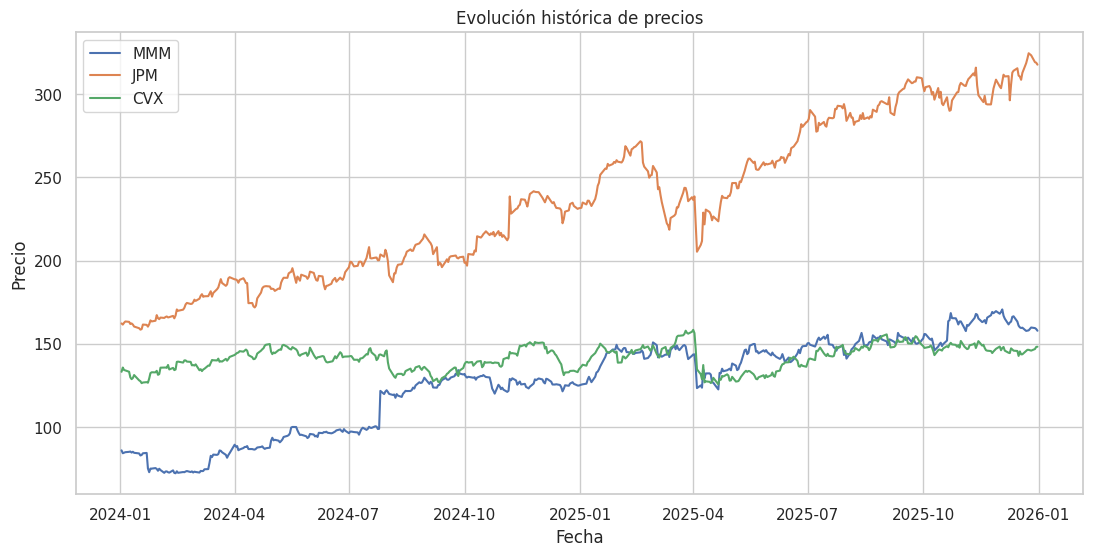

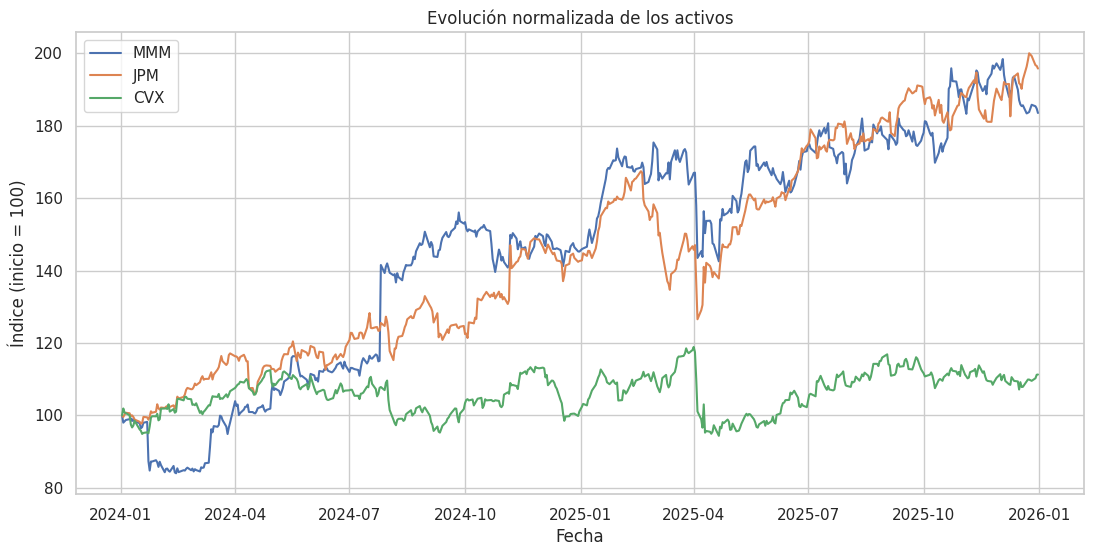

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

%matplotlib inline

from pandas import plotting

# 1. Extraer los precios de cierre
cierre = precios["Close"]

cierre.head()

# 2. Graficar precios originales
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()

# 3. Normalizar y graficar en base 100

cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()

fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()


# Respuesta Pregunta 1
Es mas viable usar el grafico normalizado porque este nos permite ver los rendimientos historicos de las empresas comparandolos entre sí; ver desde el día cero de ambas que comportamientos tuvieron y que tan volatiles fueron en las épocas, así, podemos tomar decisiones de que las puede impulsar o afectar dependiento de sus crecimientos o caidas en el tiempo.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

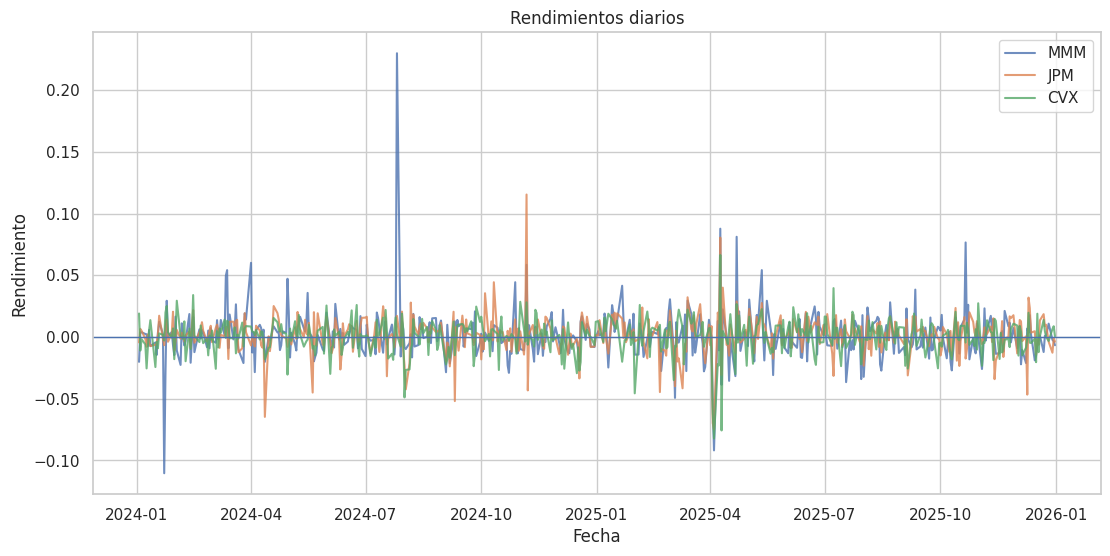

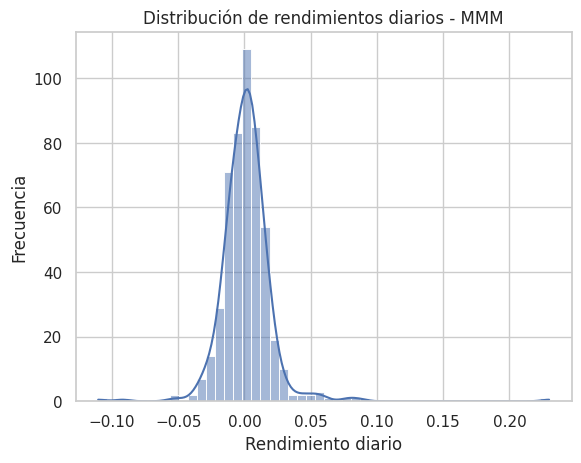

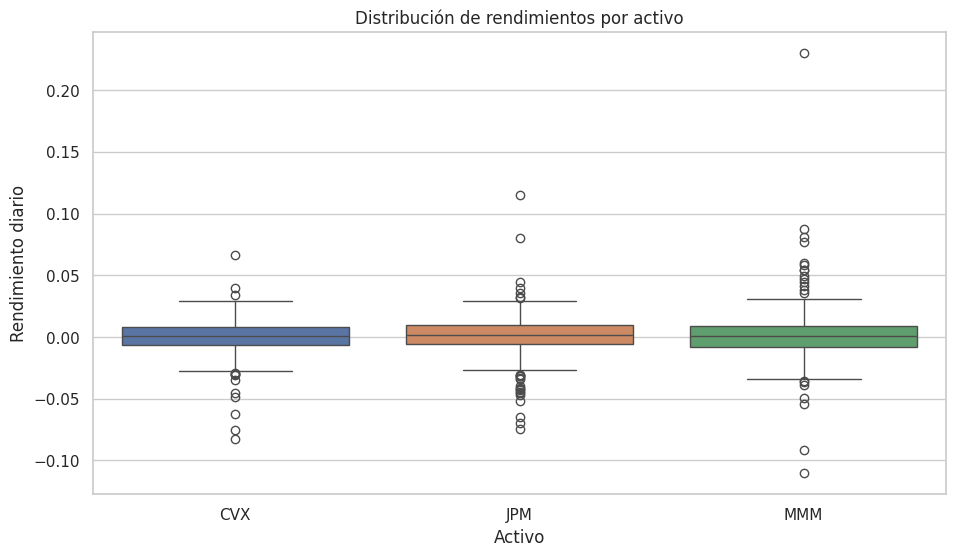

In [23]:
# 1. Calcular rendimientos
rendimientos = cierre.pct_change()

rendimientos.head()

rendimientos = rendimientos.dropna()

rendimientos.head()


# 2. Histograma con el activo más volátil
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()

sns.histplot(
    data=rendimientos,
    x="MMM",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - MMM")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()

# 3. Boxplot comparativo de rendimientos
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()


# Respuestas Pregunta 2
1. El activo que presenta mayor dispersión es "MMM", entendiento así que tiene un riesgo mayor, puede tener subidas en su rendimiento y caidas momentaneas, desestabiizando el activo.
2. No los identifico. Estos valores pueden significar una variacion grande con una caida rapida en su economía.

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

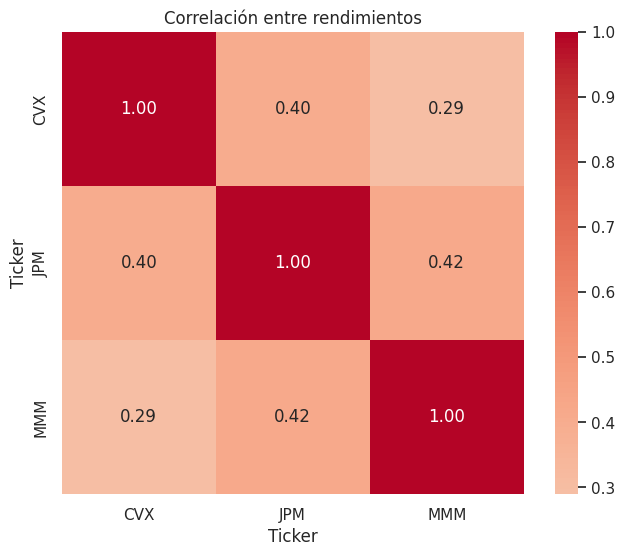

In [25]:
# 1. Calcular matriz de correlación
correlacion = rendimientos.corr()

correlacion


# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()


# Respuestas Pregunta 4
1. Si, entre los activos MMM y JPM existe una correlación positiva de 0.42, y entre CVX y MMM existe una correlación mas baja de 0.29.
2. Elegiría a MMM y CVX como mi par de activos, dado que entre ellos su correlación es baja y me permite nivelar los rendimientos de uno con el otro.

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [26]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
CVX,0.000309,0.001183,0.013784,-0.082244,0.066457
JPM,0.001457,0.001673,0.015225,-0.074838,0.115445
MMM,0.001404,0.001237,0.019937,-0.110350,0.229906


# Respuesta Pregunta 5
Mi consejo para un inversionista sería, revisar los datos historicos de todas las empresas, pero no tomar decisiones solo en base a sus rendimientos historicos, sino también revisar su economia actual y sus proyectos de inversión. En cuanto a los datos estadísticos, le recomendaría tener en cuenta que entre menos volatilidad menor riesgo tiene la empresa (en este caso CVX, que tiene unos mínimos y máximos cercanos y por ello tiene un promedio de rendimientos mas estables), también revisar la diversificación en cuanto a sus demas activos.